# Changing Langchain version

In [1]:
! pip uninstall -y langchain langchain-core langchain-community langgraph langchain-openai -q

In [2]:

! pip install \
langchain==0.3.27 \
langchain-community==0.3.29 \
langchain-openai==0.3.31 \
langgraph==0.6.6 -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-groq 1.1.3 requires langchain-core<2.0.0,>=1.4.0, but you have langchain-core 0.3.86 which is incompatible.
langchain-classic 1.0.8 requires langchain-core<2.0.0,>=1.4.4, but you have langchain-core 0.3.86 which is incompatible.
langchain-classic 1.0.8 requires langchain-text-splitters<2.0.0,>=1.1.2, but you have langchain-text-splitters 0.3.11 which is incompatible.


## Installing Groq and Tavily

This project uses Groq as a free, high-speed LLM provider for generating responses, and Tavily as a web search tool to retrieve real-time information from the internet.

Groq powers the AI reasoning layer, while Tavily enables external knowledge retrieval to support RAG (Retrieval-Augmented Generation) workflows.

In [ ]:
! pip install langchain-community
! pip install langchain langchain-openai langchain-community tavily-python py
! pip install langchain-groq

from langchain_groq import ChatGroq
from langchain_community.tools.tavily_search import TavilySearchResults
import getpass, os


if not os.environ.get("groq api key"):
    os.environ["groq api key"] = getpass.getpass("Ingresa tu GROQ_API_KEY: ")
if not os.environ.get("tvly api key"):
    os.environ["tvly api key"] = getpass.getpass("Ingresa tu TAVILY_API_KEY: ")

llm = ChatGroq(
    api_key=os.environ["groq api key"],
    model="llama-3.3-70b-versatile",
    temperature=0.3,
    max_retries=0,   
    timeout=30
)

search_tool = TavilySearchResults(
    max_results=5,
    tavily_api_key=os.environ["tvly api key"]
)

print(llm.invoke("¿Cuál es la capital de México?").content)
print(search_tool.invoke("¿Quién ganó el mundial de 1970?"))

  Using cached langchain_core-0.3.86-py3-none-any.whl.metadata (3.2 kB)
Using cached langchain_core-0.3.86-py3-none-any.whl (461 kB)
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.8
    Uninstalling langchain-core-1.4.8:
      Successfully uninstalled langchain-core-1.4.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-groq 1.1.3 requires langchain-core<2.0.0,>=1.4.0, but you have langchain-core 0.3.86 which is incompatible.
langchain-classic 1.0.8 requires langchain-core<2.0.0,>=1.4.4, but you have langchain-core 0.3.86 which is incompatible.
langchain-classic 1.0.8 requires langchain-text-splitters<2.0.0,>=1.1.2, but you have langchain-text-splitters 0.3.11 which is incompatible.
  Using cached langchain_core-1.4.8-py3-none-any.whl.metadata (4.7 kB)
Using cached langchain_core-1.4.8-py3-none-any.whl (557 k

## This creates a memory system.

If the user is a first-time user, the code will create a new conversation. However, if the user has already created a session before, it will continue the conversation using the previous chat history.

This only works while the system is running. If the system shuts down, all stored memory will be erased.

In [ ]:
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.messages import HumanMessage, AIMessage

session_memories = {}

class SessionMemory:

    def __init__(self):
        self.history = InMemoryChatMessageHistory()

    def load_memory_variables(self, _inputs):
        return {"chat_history": self.history.messages}

    def save_context(self, inputs: dict, outputs: dict):
        user_input = inputs.get("input", "")
        ai_output = outputs.get("output", "")
        if user_input:
            self.history.add_message(HumanMessage(content=user_input))
        if ai_output:
            self.history.add_message(AIMessage(content=ai_output))

def get_memory_for_session(session_id: str) -> SessionMemory:
    if session_id not in session_memories:
        session_memories[session_id] = SessionMemory()
    return session_memories[session_id]

# Installing Tools
This block installs and imports all the required libraries for the AI agent, SQL database integration, and LangGraph workflow.

In [43]:
! pip install -U langchainhub
from langchain_community.utilities import SQLDatabase
from langchain_community.tools.sql_database.tool import QuerySQLDataBaseTool
from langchain import hub
from typing import Literal
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph import MessagesState,END, START
from langgraph.types import Command
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph
from langgraph.prebuilt import create_react_agent

In [ ]:

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

print("Dialecto:", db.dialect)
print("Tablas disponibles:", db.get_usable_table_names())

Dialecto: sqlite
Tablas disponibles: ['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']


## Create a Supervisor Node 
This node acts as the system's supervisor. It analyzes the user's request along with the conversation context, determines which agent is the most appropriate to handle the task, and routes the request to the next step in the workflow. If no further action is required, it ends the conversation by directing the workflow to the finish state.

In [62]:
members=["researcher","sql_agent"]
options = members+['FINISH']

system_prompt = (
    "You are a supervisor tasked with managing a conversation between the "
    f" following workers: {members}. Given the following user request, "
    " choose the most appropriate worker to handle it. "
    " The sql_agent handles ANY question about the music store database: "
    " genres, tracks, albums, artists, customers, invoices, sales, employees, playlists, "
    " revenue, top-selling anything, counts, totals, or rankings from the data. "
    " The researcher handles ONLY general knowledge or current events questions "
    " that are NOT about the music store database (e.g. capitals, history, world news). "
    " When the conversation is complete, respond with FINISH. "
    " Consider the context of previous interactions when making your decisions."
    " Respond ONLY with a JSON object of the form {\"next\": \"<worker_or_FINISH>\"},"
    f" where <worker_or_FINISH> is exactly one of: {options}."
)

class State(MessagesState):
    next: str
    session_id: str = "default"
    context: dict = {} 
    sql_history: list = []
    last_agent: str = ""

class Router(TypedDict):
    
    next: Literal["researcher","sql_agent","FINISH"]

def supervisor_node(state: State) -> Command[Literal["researcher", "sql_agent", "__end__"]]:
    session_id = state["session_id"]
    memory = get_memory_for_session(session_id)

    messages = [
        {
            "role": "system",
            "content": system_prompt
        }
    ] + state["messages"]

    chat_history = memory.load_memory_variables({}).get("chat_history",[])
    if chat_history:
        messages[0]["content"] += f"\nChat History: {chat_history}"
    
    if state["sql_history"]:
        sql_context = "\nPrevoius SQL interactions: " + "; ".join(state["sql_history"][-3:])
        messages[0]["content"] += sql_context

    response = llm.with_structured_output(Router).invoke(messages)
    goto = response["next"]

    if goto != END:
        last_message = state["messages"][-1].content if state["messages"] else ""
        memory.save_context({"input": last_message}, {"output": goto})
        state["last_agent"] = goto

    if goto == "FINISH":
        goto = END

    return Command(
        goto=goto,
        update={
            "next": goto,
            "last_agent": state["last_agent"]
        }
    )

## Create Agent Node 

This node takes the user's last question, retrieves memory if it exists, and builds an enriched query using the conversation context. It then uses an agent equipped with search tools to generate a response and returns it to the supervisor, continuing the main workflow.

In [ ]:
def research_node(state: State) -> Command[Literal["supervisor"]]:
    session_id = state["session_id"]
    memory = get_memory_for_session(session_id)

    question = state["messages"][-1].content

    chat_history = memory.load_memory_variables({}).get("chat_history", [])

    
    search_results = search_tool.invoke(question)


    context_str = f"\nContexto previo: {chat_history}" if chat_history else ""
    prompt = f"""Eres un experto investigador. Responde la pregunta del usuario en español,
usando la siguiente información encontrada en la web.{context_str}

Pregunta: {question}

Resultados de búsqueda: {search_results}

Responde de forma clara y concisa:"""

    response = llm.invoke(prompt)

    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=response.content,
                    name="researcher"
                )
            ]
        },
        goto="supervisor"
    )

## Creating an  SQL Agent 

The workflow consist of four main steps:

1. Connect to the SQL database
2. Generate a syntactically correct SQL query using the language model 
3. Execute the query and retrieve the results 
4. Generate a natural language answer based on the query output 

In [ ]:
from langchain_community.tools.sql_database.tool import QuerySQLDataBaseTool

def sql_write_query(question: str) -> str:
   
    prompt = f"""Eres un experto en SQL. Dado el siguiente esquema de base de datos:

{db.get_table_info()}

Escribe UNA consulta SQL valida para SQLite que responda la siguiente pregunta.
Responde UNICAMENTE con el SQL, sin explicaciones, sin comentarios, sin bloques de markdown.

Pregunta: {question}
"""
    response = llm.invoke(prompt)
    query = response.content.strip()
    query = query.replace("```sql", "").replace("```", "").strip()
    return query

def sql_execute_query(query: str) -> str:   
    execute_query_tool = QuerySQLDataBaseTool(db=db)
    return execute_query_tool.invoke(query)

def sql_generate_answer(question: str, query: str, result: str) -> str:
    prompt = f"""Dada la pregunta del usuario, la consulta SQL utilizada y el resultado obtenido,
responde la pregunta en lenguaje natural (en espanol), de forma clara y concisa.

Pregunta: {question}
Consulta SQL: {query}
Resultado: {result}

Respuesta:"""
    response = llm.invoke(prompt)
    return response.content

In [ ]:
from typing import Literal
from langgraph.types import Command
from langchain_core.messages import HumanMessage

def sql_agent_node(state: State) -> Command[Literal["supervisor"]]:
    session_id = state["session_id"]
    memory = get_memory_for_session(session_id)

    question = state["messages"][-1].content
    
    query = sql_write_query(question)
    
    result = sql_execute_query(query)
    
    answer = sql_generate_answer(question, query, result)
    
    state["sql_history"].append(f"Q: {question} | SQL: {query}")
    if len(state["sql_history"]) > 10:
        state["sql_history"] = state["sql_history"][-10:]
    
    memory.save_context(
        {"input": question},
        {"output": answer}
    )

    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=answer,
                    name="sql_agent"
                )
            ],
            "sql_history": state["sql_history"]
        },
        goto="supervisor"
    )

## Define the Workflow Graphs

In [66]:
workflow = StateGraph(State)
workflow.add_node("supervisor",supervisor_node)
workflow.add_edge(START,"supervisor")
workflow.add_node("researcher",research_node)
workflow.add_node("sql_agent",sql_agent_node)
#workflow.add_edge("supervisor","researcher")
#workflow.add_edge("supervisor","sql_agent")
#workflow.add_edge("researcher","supervisor")
#workflow.add_edge("sql_agent","supervisor")
#workflow.add_edge("supervisor",END)
#workflow.set_entry_point("supervisor")
graph = workflow.compile()
                  

## Processing of the messages

In [67]:
def process_message(message: str, session_id: str = "default"):
    try:
        config = {"configurable": {"session_id": session_id}}

        initial_state = {
            "messages": [HumanMessage(content=message)],
            "session_id": session_id,
            "context": {},
            "sql_history": [],
            "last_agent": "",
            "next": "supervisor"
        }

        result = graph.invoke(initial_state, config)

        return {
            "response": result["messages"][-1].content,
            "last_agent": result.get("last_agent", ""),
            "session_id": session_id
        }
    except Exception as e:
        return {
            "error": str(e),
            "session_id": session_id
        }


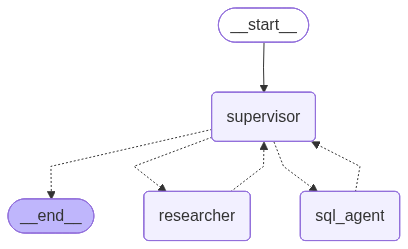

In [68]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## Testing the Model 

In [69]:
if __name__ ==  '__main__':
    sql_result = process_message("Que agente genero mas dinero en el año 2022?")
    print("SQL Query Result: ",sql_result)


SQL Query Result:  {'response': 'La agente que generó más dinero en el año 2022 fue Jane Peacock, con un total de $221.92.', 'last_agent': 'FINISH', 'session_id': 'default'}


In [72]:
if __name__ ==  '__main__':
    research_result = process_message("¿Qué es LangGraph?")
    print("\nResearch Result: ",research_result)



Research Result:  {'error': "Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kwmqmpw7fwz8f6d9f8z6cz5h` service tier `on_demand` on tokens per minute (TPM): Limit 12000, Used 11625, Requested 2247. Please try again in 9.36s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}", 'session_id': 'default'}


In [70]:
if __name__ ==  '__main__':
    followup_result = process_message("¿Cuál es el género musical más vendido?")
    print("\nFollow-up Result:",followup_result)


Follow-up Result: {'response': 'El género musical más vendido es el Rock.', 'last_agent': 'FINISH', 'session_id': 'default'}
